In [3]:
import polars as pl
import bz2
import gzip as gz
import matplotlib.pyplot as plt
import numpy as np

# KEY EDA to do

Project will involeve the flows too and from each user and we will look at binning the flows.

1) Basic checks
    Checks for duplicates number of source and destination computers, time window etc.
2) Frequency checks
    Checks for the distributions of user sent and recieved signal activity
    
list 2
1) Invesitgate the flows too and from each user how many go from each machine in a given time period.
2) Investigate variance of a machines flows over time.
3) Investigate the effect of binning width has on machine flow bias and variance.
4) Aim to indentify both human and machine operated accounts.
5) Static clustering

### Flows too and from each user and distribution of user flows

In [4]:
df = pl.scan_parquet("/home/ma/a/alb25/Project/thesis_code/data/*")

## Basic Checks

In [3]:
destinations = df.select('destination_computer').unique().collect()['destination_computer'].to_list()

In [4]:
sources = df.select('source_computer').unique().collect()['source_computer'].to_list()

In [ ]:
len(destinations)

15620

In [7]:
len(sources)

16006

In [ ]:
df.head().collect()

time,source_user@domain,destination_user@domain,source_computer,destination_computer,authentication_type,logon_type,authentication_orientation,success/failure
str,str,str,str,str,str,str,str,str
"""1""","""ANONYMOUS LOGON@C586""","""ANONYMOUS LOGON@C586""","""C1250""","""C586""","""NTLM""","""Network""","""LogOn""","""Success"""
"""1""","""ANONYMOUS LOGON@C586""","""ANONYMOUS LOGON@C586""","""C586""","""C586""","""?""","""Network""","""LogOff""","""Success"""
"""1""","""C101$@DOM1""","""C101$@DOM1""","""C988""","""C988""","""?""","""Network""","""LogOff""","""Success"""
"""1""","""C1020$@DOM1""","""SYSTEM@C1020""","""C1020""","""C1020""","""Negotiate""","""Service""","""LogOn""","""Success"""
"""1""","""C1021$@DOM1""","""C1021$@DOM1""","""C1021""","""C625""","""Kerberos""","""Network""","""LogOn""","""Success"""


In [ ]:
df.select(pl.col('time').cast(pl.Int64)).max().collect()

time
i64
5011199


In [6]:
cols = df.collect_schema().names()
df = df.with_columns(pl.struct(cols).hash(seed=0).alias('hash'))
df2 = df.select('hash').group_by('hash').len().top_k(by='len', k=5).head().collect()

In [9]:
df2

hash,len
u64,u32
10489887825803446894,1
10043600765358434665,1
17312281700719399321,1
7365033346672452035,1
6629053896398302689,1


In [ ]:
# Top authentication methods
top_auths = df.group_by('authentication_type').len().collect()
top_auths.sort(by='len', descending=True)

authentication_type,len
str,u32
"""?""",529653766
"""Kerberos""",329665951
"""NTLM""",44959119
"""Negotiate""",44944631
"""MICROSOFT_AUTHENTICATION_PACKA…",675033
…,…
"""CygwinLsa""",14
"""MICROSOFT_AUTHENTICATION_""",5
"""MICROSOFT_AUTHENTICATIO""",4


In [ ]:
df.group_by('success/failure').len().collect()

success/failure,len
str,u32
"""Success""",938810236
"""Fail""",11189764


## Frequency count check

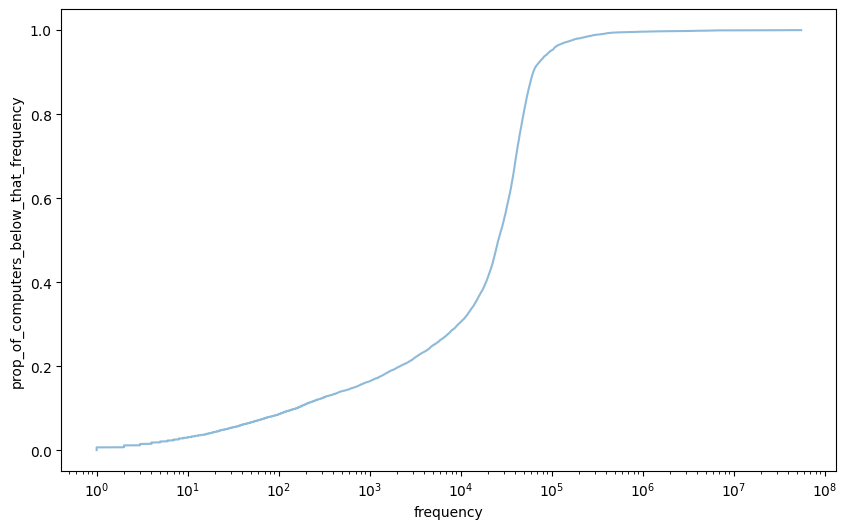

In [7]:
source_counts = df.group_by('source_computer').len().sort(by='len', descending=True).collect()
frequencies = source_counts['len'].to_list()

sorted_freqs = np.sort(frequencies)
cdf = np.arange(1, len(sorted_freqs) + 1) / len(sorted_freqs)
plt.figure(figsize=(10, 6))
plt.xscale('log')
plt.xlabel('frequency')
plt.ylabel('prop_of_computers_below_that_frequency')
plt.plot(sorted_freqs, cdf, alpha=0.5)
plt.show()

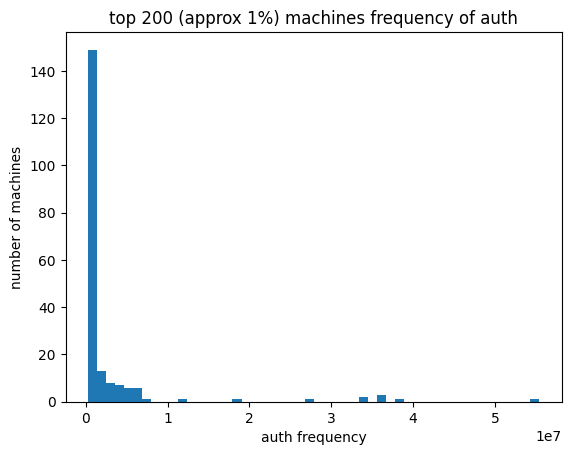

In [12]:
top_pct = source_counts.head(200)
frequencies = top_pct['len'].to_list()
plt.hist(frequencies, bins=50)
plt.title('top 200 (approx 1%) machines frequency of auth')
plt.xlabel('auth frequency')
plt.ylabel('number of machines')
plt.show()

In [ ]:
# 50 machines make up 46% of all source to destinaiton auth flows
source_counts = source_counts.with_columns((pl.col('len').cum_sum() / pl.col('len').sum() *100).alias('cumulative_pct'))
source_counts.head(50)

source_computer,len,cumulative_pct
str,u32,f64
"""C586""",50630165,5.329491
"""C612""",35137579,9.028184
"""C529""",33847062,12.591032
"""C467""",33226389,16.088547
"""C625""",32983300,19.560473
…,…,…
"""C1691""",1502911,45.467105
"""C1183""",1399748,45.614447
"""C2855""",1381941,45.759914


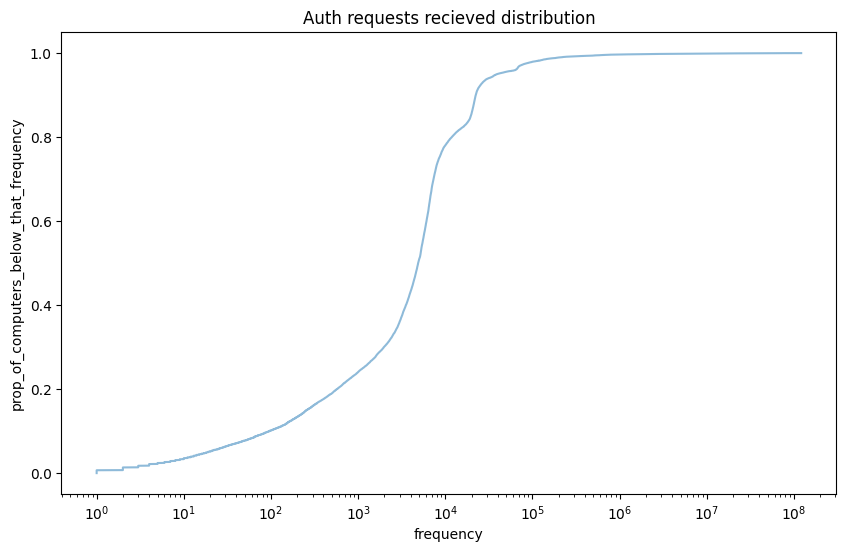

In [15]:
destination_counts = df.group_by('destination_computer').len().sort(by='len', descending=True).collect()
frequencies = destination_counts['len'].to_list()

sorted_freqs = np.sort(frequencies)
cdf = np.arange(1, len(sorted_freqs) + 1) / len(sorted_freqs)
plt.figure(figsize=(10, 6))
plt.xscale('log')
plt.xlabel('frequency')
plt.ylabel('prop_of_computers_below_that_frequency')
plt.title('Auth requests recieved distribution')
plt.plot(sorted_freqs, cdf, alpha=0.5)
plt.show()

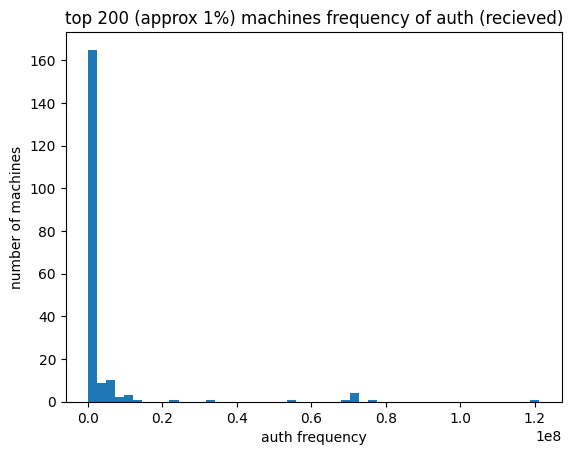

In [16]:
top_pct = destination_counts.head(200)
frequencies = top_pct['len'].to_list()
plt.hist(frequencies, bins=50)
plt.title('top 200 (approx 1%) machines frequency of auth (recieved)')
plt.xlabel('auth frequency')
plt.ylabel('number of machines')
plt.show()

In [ ]:
# Again 50 machines make up 46% of destination flows
destination_counts = source_counts.with_columns((pl.col('len').cum_sum() / pl.col('len').sum() *100).alias('cumulative_pct'))
destination_counts.head(50)

source_computer,len,cumulative_pct
str,u32,f64
"""C586""",50630165,5.329491
"""C612""",35137579,9.028184
"""C529""",33847062,12.591032
"""C467""",33226389,16.088547
"""C625""",32983300,19.560473
…,…,…
"""C1691""",1502911,45.467105
"""C1183""",1399748,45.614447
"""C2855""",1381941,45.759914


### Human vs machine account identification

In [17]:
source_users = df.select('source_user@domain').unique().collect()

In [18]:
human_users = [u[0] for u in source_users.rows() if '$' not in u[0]]

In [19]:
machine_users = [u[0] for u in source_users.rows() if '$' in u[0]]

In [6]:
print(len(machine_users))
machine_users

17586


['C17705$@DOM1',
 'C25542$@DOM1',
 'C14519$@?',
 'C7652$@?',
 'C24052$@C24052',
 'C8986$@DOM1',
 'C15606$@?',
 'C8688$@DOM1',
 'C19105$@DOM1',
 'C2676$@DOM1',
 'C2058$@DOM1',
 'C7583$@DOM1',
 'C14746$@DOM1',
 'C19744$@DOM1',
 'C21331$@DOM1',
 'C22909$@?',
 'C16249$@?',
 'C3011$@DOM1',
 'C20710$@DOM1',
 'C14676$@DOM1',
 'C5675$@DOM8',
 'C25886$@DOM1',
 'C1577$@DOM1',
 'C2733$@?',
 'C3097$@DOM1',
 'C3307$@?',
 'C17941$@DOM1',
 'C14110$@DOM1',
 'C4106$@DOM1',
 'C12989$@DOM1',
 'C11122$@DOM1',
 'C482$@DOM1',
 'C13492$@DOM1',
 'C1761$@C1761',
 'C24663$@?',
 'C12059$@?',
 'C26253$@?',
 'C16061$@DOM1',
 'C8255$@DOM1',
 'C5325$@DOM1',
 'C24788$@?',
 'C3575$@DOM1',
 'C15388$@DOM1',
 'C877$@DOM1',
 'C22811$@DOM1',
 'C12234$@DOM1',
 'C18244$@DOM1',
 'C19970$@DOM1',
 'C29$@DOM1',
 'C14445$@DOM1',
 'C1381$@DOM267',
 'C25892$@DOM1',
 'C14197$@DOM1',
 'C22980$@?',
 'C13838$@DOM1',
 'C2278$@DOM1',
 'C1361$@DOM1',
 'C1548$@DOM1',
 'C5983$@DOM1',
 'C197$@DOM1',
 'C21706$@?',
 'C5139$@DOM1',
 'C12675$@?'

In [7]:
print(len(human_users))
human_users

62967


['U5582@DOM9',
 'SYSTEM@C6874',
 'SYSTEM@C11656',
 'U2227@DOM1',
 'U637@?',
 'U10137@DOM1',
 'LOCAL SERVICE@C23005',
 'U10295@?',
 'ANONYMOUS LOGON@C23306',
 'U376@DOM9',
 'U10658@DOM1',
 'U5862@DOM1',
 'U10696@DOM1',
 'U6260@DOM9',
 'U11891@DOM1',
 'LOCAL SERVICE@C15558',
 'SYSTEM@C18469',
 'ANONYMOUS LOGON@C26498',
 'U7963@?',
 'U9421@?',
 'ANONYMOUS LOGON@C3019',
 'LOCAL SERVICE@C5771',
 'U805@?',
 'ANONYMOUS LOGON@C10888',
 'U2321@DOM1',
 'U8849@C22031',
 'U6177@DOM21',
 'NETWORK SERVICE@C5855',
 'SYSTEM@C22220',
 'U8693@?',
 'U5666@DOM9',
 'U6619@DOM1',
 'U11288@?',
 'SYSTEM@C19930',
 'U12389@DOM1',
 'U1463@DOM1',
 'U8763@DOM1',
 'SYSTEM@C23783',
 'U1006@DOM1',
 'ANONYMOUS LOGON@C11059',
 'U8818@DOM1',
 'U3233@?',
 'U4330@DOM9',
 'U4448@DOM1',
 'SYSTEM@C20013',
 'U7465@DOM9',
 'U5065@DOM1',
 'NETWORK SERVICE@C3974',
 'SYSTEM@C10616',
 'U9855@?',
 'U1375@DOM1',
 'SYSTEM@C15032',
 'U2415@?',
 'ANONYMOUS LOGON@C24071',
 'U4476@?',
 'U2921@?',
 'SYSTEM@C14891',
 'U10724@DOM9',
 'U5065

In [29]:
df.select('success/failure').unique().collect()

success/failure
str
"""Fail"""
"""Success"""


In [31]:
df.filter((pl.col('source_user@domain').is_in(machine_users)) & (pl.col('success/failure') == 'Fail')).collect().head()

time,source_user@domain,destination_user@domain,source_computer,destination_computer,authentication_type,logon_type,authentication_orientation,success/failure,hash
str,str,str,str,str,str,str,str,str,u64
"""4""","""C1149$@DOM1""","""U1325@DOM1""","""C1149""","""C1149""","""Negotiate""","""Batch""","""LogOn""","""Fail""",14834276115038065987
"""5""","""C1846$@DOM1""","""U86@DOM1""","""C1846""","""C1846""","""Negotiate""","""Batch""","""LogOn""","""Fail""",4319291380879941793
"""6""","""C3073$@DOM1""","""C3073$@DOM1""","""C3073""","""C3073""","""?""","""?""","""TGT""","""Fail""",11397060732021792
"""8""","""C1654$@DOM1""","""U86@DOM1""","""C1654""","""C1654""","""Negotiate""","""Batch""","""LogOn""","""Fail""",1282423137767563644
"""33""","""C2096$@?""","""C2096$@?""","""C457""","""C457""","""?""","""?""","""TGT""","""Fail""",5426221698002210221


In [33]:
# 
df2 = df.with_columns(
    pl.col('source_user@domain').is_in(human_users).alias('human_source')
    ).with_columns(pl.col('destination_user@domain').is_in(human_users).alias('human_destination')
    ).group_by(['human_source', 'human_destination', 'success/failure']).len().collect()

In [35]:
df2.sort(by='len', descending=True)

human_source,human_destination,success/failure,len
bool,bool,str,u32
false,false,"""Success""",620471152
true,true,"""Success""",405198267
true,true,"""Fail""",9835150
false,true,"""Success""",9722909
true,false,"""Success""",3197823
false,false,"""Fail""",2724811
false,true,"""Fail""",274631
true,false,"""Fail""",5716


### Checking the variance in flows over time

In [ ]:
df.select(pl.col("time").min().alias("min_time"), 
    pl.col("time").max().alias("max_time")).collect()

In [6]:
# Random sampled user plot

def sample_user(machine):
    """
    Samples a machine or human user and returns interaction times
    """
    if machine == True:
        user_number = np.random.randint(0, len(machine_users))
        user = machine_users[user_number]
    else:
        user_number = np.random.randint(0, len(human_users))
        user = human_users[user_number]

    user_frame = df.filter(pl.col('source_user@domain') == user).collect()
    times = user_frame.select('time').to_series().to_list()
    times = [int(t) for t in times]
    return user_frame, times

In [7]:
_, times = sample_user(machine=True)

In [8]:
def plot_times(times, xlim, vert_line = None):
    fig, ax = plt.subplots(figsize=(12, 2))
    ax.eventplot(times, orientation="horizontal")
    ax.set_yticks([])
    ax.set_xlabel("Time")
    ax.set_xlim(0, xlim)
    if vert_line is not None:
        offset = vert_line[0]
        step = vert_line[1]
        for x in range(0, xlim, step):
            ax.axvline(x-offset, color="red", linewidth=0.8, alpha=0.6)
    plt.show()

In [11]:
times

[1159970,
 1159970,
 1159970,
 1159970,
 1159970,
 1159971,
 1159975,
 1159991,
 1159992,
 1159992,
 1159992,
 1159992,
 1159993,
 1159993,
 1159993,
 1159994,
 1159999,
 1160000,
 1160005,
 1160018,
 1160022,
 1160040,
 1160050,
 1160059,
 1160059,
 1160079,
 1160610,
 1160611,
 1160611,
 1160611,
 1160611,
 1160619,
 1160619,
 1160624,
 1160643,
 1160643,
 1160654,
 1161146,
 1161146,
 1161170,
 1161544,
 1161555,
 1162113,
 1162155,
 1162156,
 1162444,
 1162445,
 1162454,
 1162455,
 1162467,
 1162476,
 1163037,
 1163345,
 1163354,
 1164244,
 1164254,
 1164275,
 1165144,
 1165154,
 1165666,
 1165666,
 1166044,
 1166054,
 1166944,
 1166954,
 1166964,
 1166973,
 1167181,
 1167181,
 1167181,
 1167182,
 1167182,
 1167182,
 1167182,
 1167190,
 1167190,
 1167206,
 1167207,
 1167207,
 1167208,
 1167208,
 1167209,
 1167209,
 1167223,
 1167229,
 1167232,
 1167256,
 1167258,
 1167284,
 1167844,
 1167844,
 1167854,
 1167854,
 1167866,
 1167988,
 1167989,
 1168477,
 1168744,
 1168755,
 1168978,


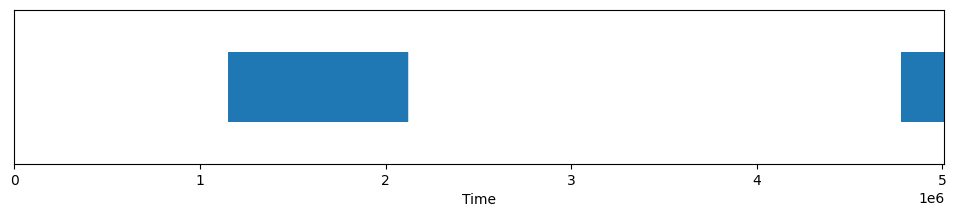

In [ ]:
# Max time in df is 5011199

#v = (250, 900)
v = None
xlim = 5011199
plot_times(times, xlim = xlim, vert_line=v)

In [52]:
# Random sampled machines flow plot and variance
df.head().collect()

time,source_user@domain,destination_user@domain,source_computer,destination_computer,authentication_type,logon_type,authentication_orientation,success/failure
str,str,str,str,str,str,str,str,str
"""1""","""ANONYMOUS LOGON@C586""","""ANONYMOUS LOGON@C586""","""C1250""","""C586""","""NTLM""","""Network""","""LogOn""","""Success"""
"""1""","""ANONYMOUS LOGON@C586""","""ANONYMOUS LOGON@C586""","""C586""","""C586""","""?""","""Network""","""LogOff""","""Success"""
"""1""","""C101$@DOM1""","""C101$@DOM1""","""C988""","""C988""","""?""","""Network""","""LogOff""","""Success"""
"""1""","""C1020$@DOM1""","""SYSTEM@C1020""","""C1020""","""C1020""","""Negotiate""","""Service""","""LogOn""","""Success"""
"""1""","""C1021$@DOM1""","""C1021$@DOM1""","""C1021""","""C625""","""Kerberos""","""Network""","""LogOn""","""Success"""


In [ ]:
# Checking for duplicates
df.group_by(['time', 'source_user@domain', 'destination_user@domain', 'source_computer', 'destination_computer', 'authentication_type', 'logon_type', 'authentication_orientation', 'success/failure']).len().sort(by='len').head().collect()

### Noteworthy findings

#### Section 1
No duplicates found


Clear distinction between human and machine users in the dataframe dermakated by $
Clear periodic behaviour observed for some machine users
Multiple requests made within identical time periods common

In [ ]:
#### Example of clearly automated regular machine behaviour

![image.png](attachment:image.png)

/bin/bash: -c: line 1: syntax error near unexpected token `attachment:image.png'
/bin/bash: -c: line 1: `[image.png](attachment:image.png)'


In [ ]:
# Example of multiple requests in the same window
_.head()

time,source_user@domain,destination_user@domain,source_computer,destination_computer,authentication_type,logon_type,authentication_orientation,success/failure
str,str,str,str,str,str,str,str,str
"""1422360""","""C23653$@DOM1""","""C23653$@DOM1""","""C23653""","""C23653""","""?""","""?""","""TGT""","""Success"""
"""1422360""","""C23653$@DOM1""","""C23653$@DOM1""","""C23653""","""C528""","""?""","""?""","""TGS""","""Success"""
"""1422360""","""C23653$@DOM1""","""C23653$@DOM1""","""C23653""","""C528""","""Kerberos""","""Network""","""LogOn""","""Success"""
"""1422360""","""C23653$@DOM1""","""C23653$@DOM1""","""C23653""","""TGT""","""?""","""?""","""TGS""","""Success"""
"""1422371""","""C23653$@DOM1""","""C23653$@DOM1""","""C528""","""C528""","""?""","""Network""","""LogOff""","""Success"""
